# Collocation Point Sampling

This notebook summarizes the collocation sampling experiment for thesis-ready reporting. The comparison covers uniform LHS collocation, periodic random resampling, and RAD across three collocation densities.

Pipeline script: `src/experiments/pipeline/run_collocation_comparison.py`  
Raw outputs: `outputs/collocation_comparison/`  
Table exports: `results/tables/04_collocation_comparison/`

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def _find_repo_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {start}")

REPO = _find_repo_root()

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterSciNotation, LogLocator
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from omegaconf import OmegaConf

from src.pinn.collocation.scoring import score_collocation_points
from src.sim.ode.model_definitions import SynchronousMachineModels
from src.training.trainer import PinnModel
from src.visualization.results_helpers import (
    aggregate_mean_sem,
    artifact_path,
    epoch_metrics_path,
    ensure_repo_root_on_path,
    load_json,
    load_posthoc_external_eval,
    mean_sem_text,
    overlay_posthoc_external_eval,
    read_epoch_metrics,
    seed_list,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    log_minor_grid,
    method_color,
    save_figure,
    set_thesis_style,
)

REPO = ensure_repo_root_on_path(REPO)
ROOT = REPO / "outputs" / "collocation_comparison"
EXPORT = REPO / "results" / "data" / "thesis_04_collocation_comparison"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("collocation_comparison")

set_thesis_style()

STRATEGY_ORDER = ["uniform_lhs", "random_resampling", "rad"]
DENSITY_ORDER = ["p4k", "p32k", "p64k"]
EXPECTED_SEEDS = ["s01", "s02", "s03"]

STRATEGY_LABEL = {
    "uniform_lhs": "Uniform LHS",
    "random_resampling": "Random resampling",
    "rad": "RAD",
}
DENSITY_LABEL = {
    "p4k": "4k",
    "p32k": "32k",
    "p64k": "64k",
}
STRATEGY_COLORS = {
    "uniform_lhs": NEUTRAL_COLORS["muted"],
    "random_resampling": DTU_COLORS["blue"],
    "rad": DTU_COLORS["corporate_red"],
}


def strategy_label(strategy: str) -> str:
    return STRATEGY_LABEL.get(str(strategy), str(strategy))


def density_label(density: str) -> str:
    return DENSITY_LABEL.get(str(density), str(density))


def export_fig(fig, name: str):
    # Figure export disabled for repository submission; keep plot inline.
    paths = []
    # paths = save_figure(fig, EXPORT / name, formats=("pdf", "svg", "png"))
    plt.show()
    return paths


def ordered(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "density_label" in out.columns:
        out["density_label"] = pd.Categorical(out["density_label"].astype(str), categories=DENSITY_ORDER, ordered=True)
    if "strategy" in out.columns:
        out["strategy"] = pd.Categorical(out["strategy"].astype(str), categories=STRATEGY_ORDER, ordered=True)
    sort_cols = [col for col in ["density_label", "strategy", "seed_label"] if col in out.columns]
    return out.sort_values(sort_cols).reset_index(drop=True)


## Data Loading

Timestamped batch folders are combined into one run table. The posthoc checkpoint evaluation is overlaid before aggregation so the thesis metrics use the exclusive external OOD definition.

In [2]:
summary_frames = []
manifest_rows = []
for batch_dir in sorted(ROOT.glob("*")):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    artifacts = manifest.get("artifacts", {})
    manifest_runs = manifest.get("runs", [])
    manifest_rows.append({
        "batch": batch_dir.name,
        "summary_present": (batch_dir / "summary.csv").exists(),
        "manifest_runs": len(manifest_runs),
        "manifest_completed": sum(1 for run in manifest_runs if run.get("status") == "completed"),
        "strategies": artifacts.get("strategies"),
        "density_labels": artifacts.get("density_labels"),
        "seed_labels": artifacts.get("seed_labels"),
        "epochs": artifacts.get("epochs"),
        "adam_lr": artifacts.get("adam_lr"),
        "dataset_reference_id": artifacts.get("dataset_reference_id"),
        "id_eval_id": artifacts.get("id_eval_id"),
        "ood_eval_id": artifacts.get("ood_eval_id"),
    })
    summary_path = batch_dir / "summary.csv"
    if summary_path.exists():
        frame = pd.read_csv(summary_path)
        frame["batch"] = batch_dir.name
        summary_frames.append(frame)

if not summary_frames:
    raise FileNotFoundError(f"No summary.csv files found under {ROOT}")

runs = pd.concat(summary_frames, ignore_index=True, sort=False)
posthoc_eval = load_posthoc_external_eval(ROOT, setting="best_train_exclusive_ood")
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")

runs = overlay_posthoc_external_eval(runs, posthoc_eval)
runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
runs["has_complete_external_eval"] = runs[["best_id_eval_mse", "best_ood_eval_mse"]].notna().all(axis=1)
runs = ordered(runs)

manifests = pd.DataFrame(manifest_rows).sort_values("batch").reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.
# manifests.to_csv(EXPORT / "batches.csv", index=False)
# runs.to_csv(EXPORT / "runs.csv", index=False)

print(f"Loaded {len(runs)} runs from {len(manifests)} batches.")
print(f"Posthoc completed: {int(runs['has_posthoc_eval'].sum())}/{len(runs)}")
display(manifests)
display(runs[["batch", "run_name", "density_label", "strategy", "seed_label", "status", "has_posthoc_eval", "has_complete_external_eval"]])


Loaded 27 runs from 9 batches.
Posthoc completed: 27/27


,batch,summary_present,manifest_runs,manifest_completed,strategies,density_labels,seed_labels,epochs,adam_lr,dataset_reference_id,id_eval_id,ood_eval_id
0,20260513_153942,True,3,3,[uniform_lhs],[p4k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
1,20260514_032532,True,3,3,[rad],[p4k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
2,20260514_124756,True,3,3,[random_resampling],[p4k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
3,20260515_024023,True,3,3,[uniform_lhs],[p32k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
4,20260515_222706,True,3,3,[random_resampling],[p32k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
5,20260516_053831,True,3,3,[rad],[p32k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
6,20260520_040053,True,3,3,[uniform_lhs],[p64k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
7,20260521_035332,True,3,3,[random_resampling],[p64k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01
8,20260521_061925,True,3,3,[rad],[p64k],"[s01, s02, s03]",4850,0.003,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01


,batch,run_name,density_label,strategy,seed_label,status,has_posthoc_eval,has_complete_external_eval
0,20260513_153942,uniform_lhs_p4k_c500_s01_adam_lbfgs150,p4k,uniform_lhs,s01,completed,True,True
1,20260513_153942,uniform_lhs_p4k_c500_s02_adam_lbfgs150,p4k,uniform_lhs,s02,completed,True,True
2,20260513_153942,uniform_lhs_p4k_c500_s03_adam_lbfgs150,p4k,uniform_lhs,s03,completed,True,True
3,20260514_124756,random_resampling_p4k_c500_s01_adam_lbfgs150,p4k,random_resampling,s01,completed,True,True
4,20260514_124756,random_resampling_p4k_c500_s02_adam_lbfgs150,p4k,random_resampling,s02,completed,True,True
5,20260514_124756,random_resampling_p4k_c500_s03_adam_lbfgs150,p4k,random_resampling,s03,completed,True,True
6,20260514_032532,rad_p4k_c500_s01_adam_lbfgs150,p4k,rad,s01,completed,True,True
7,20260514_032532,rad_p4k_c500_s02_adam_lbfgs150,p4k,rad,s02,completed,True,True
8,20260514_032532,rad_p4k_c500_s03_adam_lbfgs150,p4k,rad,s03,completed,True,True
9,20260515_024023,uniform_lhs_p32k_c500_s01_adam_lbfgs150,p32k,uniform_lhs,s01,completed,True,True


## Completeness

In [3]:
completion_rows = []
for density in DENSITY_ORDER:
    for strategy in STRATEGY_ORDER:
        subset = runs[(runs["density_label"].astype(str) == density) & (runs["strategy"].astype(str) == strategy)]
        present = sorted(subset["seed_label"].dropna().astype(str).unique())
        posthoc_complete = sorted(subset.loc[subset["has_posthoc_eval"], "seed_label"].dropna().astype(str).unique())
        missing = [seed for seed in EXPECTED_SEEDS if seed not in present]
        completion_rows.append({
            "Density": density_label(density),
            "Strategy": strategy_label(strategy),
            "Seeds present": ", ".join(present) if present else "n/a",
            "Posthoc seeds": ", ".join(posthoc_complete) if posthoc_complete else "n/a",
            "Missing expected seeds": ", ".join(missing) if missing else "none",
            "n": len(subset),
        })
completion = pd.DataFrame(completion_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# completion.to_csv(EXPORT / "completion.csv", index=False)
display(completion)


,Density,Strategy,Seeds present,Posthoc seeds,Missing expected seeds,n
0,4k,Uniform LHS,"s01, s02, s03","s01, s02, s03",none,3
1,4k,Random resampling,"s01, s02, s03","s01, s02, s03",none,3
2,4k,RAD,"s01, s02, s03","s01, s02, s03",none,3
3,32k,Uniform LHS,"s01, s02, s03","s01, s02, s03",none,3
4,32k,Random resampling,"s01, s02, s03","s01, s02, s03",none,3
5,32k,RAD,"s01, s02, s03","s01, s02, s03",none,3
6,64k,Uniform LHS,"s01, s02, s03","s01, s02, s03",none,3
7,64k,Random resampling,"s01, s02, s03","s01, s02, s03",none,3
8,64k,RAD,"s01, s02, s03","s01, s02, s03",none,3


## Thesis Summary Table

Mean values and SEM are computed across the three model seeds for each density and sampling strategy. ID/OOD metrics come from the posthoc checkpoint evaluation with exclusive OOD filtering.

In [4]:
POSTHOC_SUMMARY_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90",
    "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_id_eval_trajectory_rmse_mean", "best_id_eval_trajectory_rmse_p90",
    "best_id_eval_trajectory_rmse_p95", "best_id_eval_trajectory_rmse_max",
    "best_id_eval_trajectory_max_abs_error_mean",
    "best_id_eval_trajectory_max_abs_error_p95",
    "best_id_eval_trajectory_max_abs_error_max",
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90",
    "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_rmse_mean", "best_ood_eval_trajectory_rmse_p90",
    "best_ood_eval_trajectory_rmse_p95", "best_ood_eval_trajectory_rmse_max",
    "best_ood_eval_trajectory_max_abs_error_mean",
    "best_ood_eval_trajectory_max_abs_error_p95",
    "best_ood_eval_trajectory_max_abs_error_max",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
]
POSTHOC_METRIC_LABELS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_rmse", "ID RMSE"),
    ("best_id_eval_mae", "ID MAE"),
    ("best_id_eval_max_abs_error", "ID max abs error"),
    ("best_id_eval_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("best_id_eval_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("best_id_eval_trajectory_mse_max", "ID trajectory MSE max"),
    ("best_id_eval_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("best_id_eval_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("best_id_eval_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("best_id_eval_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("best_id_eval_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("best_id_eval_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("best_id_eval_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("best_id_eval_n_rows", "ID rows"),
    ("best_id_eval_n_trajectories", "ID trajectories"),
    ("best_ood_eval_mse", "OOD MSE"),
    ("best_ood_eval_rmse", "OOD RMSE"),
    ("best_ood_eval_mae", "OOD MAE"),
    ("best_ood_eval_max_abs_error", "OOD max abs error"),
    ("best_ood_eval_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("best_ood_eval_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("best_ood_eval_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("best_ood_eval_trajectory_mse_max", "OOD trajectory MSE max"),
    ("best_ood_eval_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("best_ood_eval_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("best_ood_eval_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("best_ood_eval_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("best_ood_eval_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("best_ood_eval_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("best_ood_eval_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("best_ood_eval_n_rows_before_filter", "OOD rows before filter"),
    ("best_ood_eval_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("best_ood_eval_n_rows", "OOD rows"),
    ("best_ood_eval_n_trajectories", "OOD trajectories"),
]
COUNT_METRICS = {
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
}
SUMMARY_METRICS = POSTHOC_SUMMARY_METRICS + ["final_test_mse", "training_seconds", "total_seconds"]

thesis_numeric = aggregate_mean_sem(
    runs,
    group_cols=["density_label", "strategy"],
    metrics=SUMMARY_METRICS,
    order_col="density_label",
    order=DENSITY_ORDER,
)
thesis_numeric["strategy"] = pd.Categorical(thesis_numeric["strategy"].astype(str), categories=STRATEGY_ORDER, ordered=True)
thesis_numeric = thesis_numeric.sort_values(["density_label", "strategy"]).reset_index(drop=True)
write_numeric_table(thesis_numeric, "collocation_comparison")


def metric_text(row: pd.Series, metric: str, *, decimals: int = 2, scientific: bool = True) -> str:
    if pd.isna(row.get(f"{metric}_mean")) and pd.isna(row.get(f"{metric}_sem")):
        return "n/a"
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)

rows = []
for _, row in thesis_numeric.iterrows():
    record = {
        "Density": density_label(row["density_label"]),
        "Strategy": strategy_label(row["strategy"]),
        "Seeds": row.get("seeds", ""),
    }
    for metric, label in POSTHOC_METRIC_LABELS:
        if metric in COUNT_METRICS:
            record[label] = metric_text(row, metric, decimals=0, scientific=False)
        else:
            record[label] = metric_text(row, metric, decimals=2, scientific=True)
    record["test MSE"] = metric_text(row, "final_test_mse", decimals=2, scientific=True)
    record["training time [s]"] = metric_text(row, "training_seconds", decimals=1, scientific=False)
    record["total time [s]"] = metric_text(row, "total_seconds", decimals=1, scientific=False)
    rows.append(record)

thesis_table = pd.DataFrame(rows)
write_table(thesis_table, "collocation_comparison")
display(thesis_table)


,Density,Strategy,Seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,...,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,test MSE,training time [s],total time [s]
0,4k,Uniform LHS,"s01,s02,s03",2.98e-06 +/- 3.72e-07,1.72e-03 +/- 1.05e-04,1.06e-03 +/- 8.62e-05,3.01e-02 +/- 3.75e-03,2.98e-06 +/- 3.72e-07,5.92e-06 +/- 5.52e-07,8.25e-06 +/- 4.75e-07,...,1.87e-01 +/- 2.44e-03,8.30e-01 +/- 9.29e-03,1.20e+00 +/- 1.96e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.22e-06 +/- 3.47e-07,6884.1 +/- 32.8,6889.4 +/- 32.9
1,4k,Random resampling,"s01,s02,s03",2.88e-06 +/- 5.79e-07,1.68e-03 +/- 1.68e-04,1.00e-03 +/- 1.04e-04,2.95e-02 +/- 3.75e-03,2.88e-06 +/- 5.79e-07,5.98e-06 +/- 1.06e-06,9.26e-06 +/- 2.17e-06,...,1.96e-01 +/- 4.36e-03,8.58e-01 +/- 5.77e-03,1.24e+00 +/- 2.08e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.55e-06 +/- 5.52e-07,6979.4 +/- 7.9,6984.8 +/- 7.9
2,4k,RAD,"s01,s02,s03",3.02e-06 +/- 4.75e-07,1.73e-03 +/- 1.40e-04,1.06e-03 +/- 9.94e-05,2.60e-02 +/- 9.91e-04,3.02e-06 +/- 4.75e-07,6.20e-06 +/- 7.43e-07,8.90e-06 +/- 1.71e-06,...,1.91e-01 +/- 1.30e-03,8.45e-01 +/- 4.66e-03,1.26e+00 +/- 1.90e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.78e-06 +/- 9.82e-07,7187.9 +/- 15.0,7193.6 +/- 15.5
3,32k,Uniform LHS,"s01,s02,s03",3.13e-06 +/- 2.95e-07,1.76e-03 +/- 8.23e-05,1.08e-03 +/- 4.76e-05,3.73e-02 +/- 3.64e-03,3.13e-06 +/- 2.95e-07,6.60e-06 +/- 6.60e-07,9.17e-06 +/- 1.01e-06,...,1.87e-01 +/- 3.10e-03,8.25e-01 +/- 1.61e-02,1.18e+00 +/- 5.29e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,4.72e-06 +/- 1.59e-06,6967.2 +/- 15.7,6977.4 +/- 20.6
4,32k,Random resampling,"s01,s02,s03",2.90e-06 +/- 4.43e-07,1.69e-03 +/- 1.31e-04,1.04e-03 +/- 7.96e-05,2.57e-02 +/- 9.59e-04,2.90e-06 +/- 4.43e-07,5.72e-06 +/- 8.40e-07,8.70e-06 +/- 1.87e-06,...,1.93e-01 +/- 6.26e-03,8.40e-01 +/- 2.84e-02,1.26e+00 +/- 7.33e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.17e-06 +/- 5.63e-07,6774.3 +/- 12.6,6781.1 +/- 13.1
5,32k,RAD,"s01,s02,s03",2.53e-06 +/- 4.04e-07,1.58e-03 +/- 1.31e-04,9.80e-04 +/- 8.72e-05,2.66e-02 +/- 2.84e-03,2.53e-06 +/- 4.04e-07,5.16e-06 +/- 8.08e-07,6.84e-06 +/- 1.24e-06,...,1.97e-01 +/- 4.71e-03,8.73e-01 +/- 8.27e-03,1.30e+00 +/- 5.27e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.41e-06 +/- 1.03e-06,6840.6 +/- 34.4,6845.9 +/- 34.4
6,64k,Uniform LHS,"s01,s02,s03",3.23e-06 +/- 8.25e-07,1.77e-03 +/- 2.20e-04,1.07e-03 +/- 1.43e-04,2.64e-02 +/- 2.35e-03,3.23e-06 +/- 8.25e-07,6.64e-06 +/- 1.80e-06,9.27e-06 +/- 2.36e-06,...,1.88e-01 +/- 4.97e-04,8.35e-01 +/- 3.96e-03,1.19e+00 +/- 3.99e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.02e-06 +/- 1.56e-07,6917.3 +/- 36.0,6922.7 +/- 36.3
7,64k,Random resampling,"s01,s02,s03",3.40e-06 +/- 9.08e-07,1.81e-03 +/- 2.36e-04,1.12e-03 +/- 1.43e-04,3.02e-02 +/- 5.04e-03,3.40e-06 +/- 9.08e-07,6.65e-06 +/- 1.83e-06,8.97e-06 +/- 2.03e-06,...,1.89e-01 +/- 2.23e-03,8.35e-01 +/- 9.65e-03,1.19e+00 +/- 4.63e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.37e-06 +/- 7.00e-07,6763.3 +/- 51.6,6774.7 +/- 48.1
8,64k,RAD,"s01,s02,s03",2.53e-06 +/- 2.64e-07,1.59e-03 +/- 8.48e-05,9.49e-04 +/- 6.71e-05,2.56e-02 +/- 2.56e-03,2.53e-06 +/- 2.64e-07,5.37e-06 +/- 5.46e-07,7.66e-06 +/- 7.44e-07,...,1.96e-01 +/- 3.81e-03,8.62e-01 +/- 1.43e-02,1.20e+00 +/- 2.88e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.00e-06 +/- 4.65e-07,6233.5 +/- 3.7,6243.5 +/- 7.1


## Final Validation Loss Decomposition

The table below reports the final-epoch validation loss decomposition from `epoch_metrics.csv`, aggregated across seeds for each collocation density and sampling strategy.

In [5]:
VAL_LOSS_COLUMNS = [
    "val_total_loss",
    "val_data_loss",
    "val_ic_loss",
    "val_dt_loss",
    "val_physics_loss",
]
VAL_LOSS_LABELS = [
    ("val_total_loss", "validation total loss"),
    ("val_data_loss", "validation data loss"),
    ("val_ic_loss", "validation IC loss"),
    ("val_dt_loss", "validation dt loss"),
    ("val_physics_loss", "validation physics loss"),
]

val_loss_rows = []
for _, run in runs.iterrows():
    path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(path, columns=["global_epoch", *VAL_LOSS_COLUMNS])
    if epoch_frame.empty or "global_epoch" not in epoch_frame.columns:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    if epoch_frame.empty:
        continue
    final_epoch = int(pd.to_numeric(epoch_frame["global_epoch"], errors="coerce").max())
    final_rows = epoch_frame[pd.to_numeric(epoch_frame["global_epoch"], errors="coerce") == final_epoch]
    if final_rows.empty:
        continue
    final = final_rows.iloc[-1]
    val_loss_rows.append({
        "batch": run["batch"],
        "run_name": run["run_name"],
        "density_label": run["density_label"],
        "strategy": run["strategy"],
        "seed_label": run["seed_label"],
        "final_epoch": final_epoch,
        **{metric: final.get(metric, np.nan) for metric in VAL_LOSS_COLUMNS},
    })

final_val_losses = ordered(pd.DataFrame(val_loss_rows)) if val_loss_rows else pd.DataFrame()
if final_val_losses.empty:
    raise FileNotFoundError("No final validation loss rows could be read from epoch_metrics.csv files.")
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_losses.to_csv(EXPORT / "final_validation_losses_run_level.csv", index=False)

final_val_loss_numeric = aggregate_mean_sem(
    final_val_losses,
    group_cols=["density_label", "strategy"],
    metrics=["final_epoch", *VAL_LOSS_COLUMNS],
    seed_col="seed_label",
    run_col="run_name",
    order_col="density_label",
    order=DENSITY_ORDER,
)
final_val_loss_numeric["strategy"] = pd.Categorical(final_val_loss_numeric["strategy"].astype(str), categories=STRATEGY_ORDER, ordered=True)
final_val_loss_numeric = final_val_loss_numeric.sort_values(["density_label", "strategy"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_loss_numeric.to_csv(EXPORT / "final_validation_losses_table_numeric.csv", index=False)

rows = []
for _, row in final_val_loss_numeric.iterrows():
    record = {
        "Density": density_label(row["density_label"]),
        "Strategy": strategy_label(row["strategy"]),
        "Seeds": row.get("seeds", ""),
        "final epoch": mean_sem_text(row, "final_epoch", decimals=0, scientific=False),
    }
    for metric, label in VAL_LOSS_LABELS:
        record[label] = mean_sem_text(row, metric, decimals=2, scientific=True)
    rows.append(record)

final_val_loss_table = pd.DataFrame(rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_loss_table.to_csv(EXPORT / "final_validation_losses_table.csv", index=False)
display(final_val_loss_table)


,Density,Strategy,Seeds,final epoch,validation total loss,validation data loss,validation IC loss,validation dt loss,validation physics loss
0,4k,Uniform LHS,"s01,s02,s03",5000 +/- 0,3.85e-06 +/- 5.46e-07,3.62e-06 +/- 5.42e-07,1.59e-05 +/- 1.16e-06,9.96e-04 +/- 8.86e-05,1.21e-03 +/- 3.54e-05
1,4k,Random resampling,"s01,s02,s03",5000 +/- 0,3.74e-06 +/- 4.83e-07,3.48e-06 +/- 4.88e-07,2.27e-05 +/- 2.66e-06,9.96e-04 +/- 7.89e-05,1.37e-03 +/- 1.56e-04
2,4k,RAD,"s01,s02,s03",5000 +/- 0,3.46e-06 +/- 5.97e-07,3.24e-06 +/- 5.98e-07,1.71e-05 +/- 3.49e-06,8.17e-04 +/- 3.37e-05,1.17e-03 +/- 8.61e-05
3,32k,Uniform LHS,"s01,s02,s03",5000 +/- 0,5.17e-06 +/- 1.80e-06,4.98e-06 +/- 1.79e-06,1.97e-05 +/- 3.55e-06,8.39e-04 +/- 5.63e-05,8.84e-04 +/- 8.72e-05
4,32k,Random resampling,"s01,s02,s03",5000 +/- 0,3.07e-06 +/- 4.28e-07,2.87e-06 +/- 4.20e-07,1.84e-05 +/- 2.27e-06,7.92e-04 +/- 3.46e-05,9.65e-04 +/- 7.09e-05
5,32k,RAD,"s01,s02,s03",5000 +/- 0,2.92e-06 +/- 2.95e-07,2.78e-06 +/- 2.96e-07,1.26e-05 +/- 1.35e-06,5.71e-04 +/- 3.99e-05,7.36e-04 +/- 6.09e-05
6,64k,Uniform LHS,"s01,s02,s03",5000 +/- 0,3.36e-06 +/- 4.70e-07,3.20e-06 +/- 4.65e-07,1.44e-05 +/- 1.08e-06,7.87e-04 +/- 4.74e-05,7.58e-04 +/- 5.24e-05
7,64k,Random resampling,"s01,s02,s03",5000 +/- 0,3.64e-06 +/- 7.48e-07,3.45e-06 +/- 7.29e-07,1.52e-05 +/- 1.17e-06,7.96e-04 +/- 1.03e-04,1.00e-03 +/- 1.81e-04
8,64k,RAD,"s01,s02,s03",5000 +/- 0,2.86e-06 +/- 3.25e-07,2.73e-06 +/- 3.24e-07,1.16e-05 +/- 1.16e-06,5.08e-04 +/- 1.06e-05,6.91e-04 +/- 1.10e-05


## Next Figures

The remaining sections will add the thesis-ready plots from the original collocation notebook: final validation component scales, relative improvements versus uniform LHS, and ID/OOD generalization behavior.

## ID Accuracy Across Collocation Density

Grouped bars compare the posthoc ID metrics across collocation densities and sampling methods.

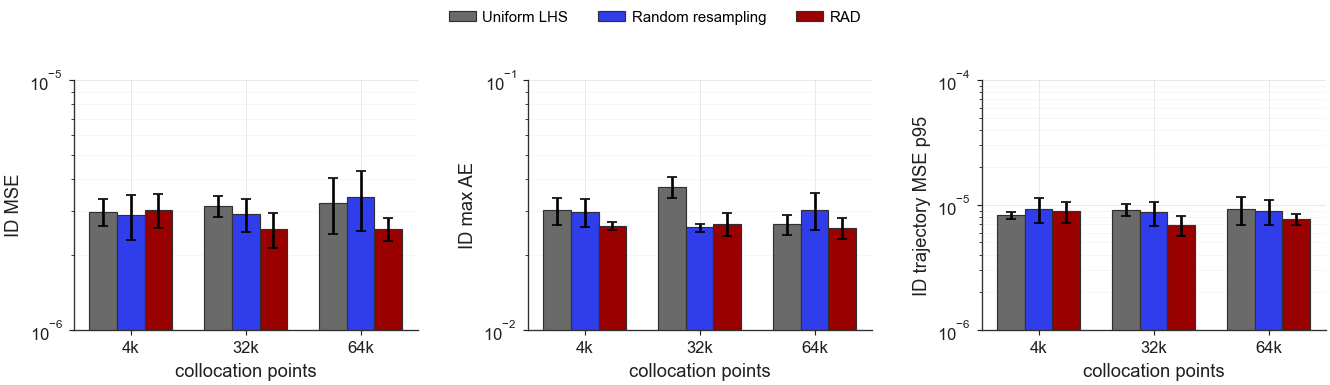

[]

In [6]:
ID_BAR_SPECS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_max_abs_error", "ID max AE"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
]


def log_limits(values: np.ndarray, errors: np.ndarray) -> tuple[float, float]:
    lower = values - np.nan_to_num(errors, nan=0.0)
    upper = values + np.nan_to_num(errors, nan=0.0)
    lower = lower[np.isfinite(lower) & (lower > 0)]
    upper = upper[np.isfinite(upper) & (upper > 0)]
    if len(lower) == 0 or len(upper) == 0:
        return 1e-8, 1.0
    ymin = 10 ** np.floor(np.log10(lower.min()))
    ymax = 10 ** np.ceil(np.log10(upper.max()))
    if ymin == ymax:
        ymax *= 10
    return ymin, ymax

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.25), sharex=True)
x = np.arange(len(DENSITY_ORDER))
width = 0.24
for ax, (metric, ylabel) in zip(axes, ID_BAR_SPECS):
    panel_values = []
    panel_errors = []
    for offset_idx, strategy in enumerate(STRATEGY_ORDER):
        sub = (
            thesis_numeric[thesis_numeric["strategy"].astype(str) == strategy]
            .set_index("density_label")
            .reindex(DENSITY_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        errs = np.nan_to_num(sub[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0)
        panel_values.append(means)
        panel_errors.append(errs)
        ax.bar(
            x + (offset_idx - 1) * width,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            color=STRATEGY_COLORS[strategy],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=strategy_label(strategy),
        )
    values = np.concatenate(panel_values)
    errors = np.concatenate(panel_errors)
    ax.set_ylim(*log_limits(values, errors))
    ax.set_xticks(x)
    ax.set_xticklabels([density_label(d) for d in DENSITY_ORDER])
    ax.set_xlabel("collocation points")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=20))
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.03))
fig.subplots_adjust(left=0.075, right=0.990, bottom=0.180, top=0.820, wspace=0.320)
export_fig(fig, "collocation_id_metrics_grouped_bars")


## Posthoc RAD Sampling Diagnostic

This diagnostic visualizes a representative residual landscape and compares uniform samples with RAD-style samples drawn from that same posthoc residual field. It is an interpretability plot, not the exact collocation set saved during training; the original active RAD point clouds were not persisted.

In [7]:
DIAGNOSTIC_DENSITY = "p64k"
DIAGNOSTIC_SEED = "s01"
DIAGNOSTIC_THETA_POINTS = 70
DIAGNOSTIC_TIME_POINTS = 90
DIAGNOSTIC_CANDIDATES = 6_000
DIAGNOSTIC_OVERLAY_POINTS = 800
DIAGNOSTIC_BATCH_SIZE = 1_024
DIAGNOSTIC_LOG_EPS = 1.0e-12


def representative_run(strategy: str, *, density: str = DIAGNOSTIC_DENSITY, seed: str = DIAGNOSTIC_SEED) -> pd.Series:
    subset = runs[
        (runs["strategy"].astype(str) == strategy)
        & (runs["density_label"].astype(str) == density)
        & (runs["seed_label"].astype(str) == seed)
    ]
    if subset.empty:
        raise ValueError(f"No run found for strategy={strategy}, density={density}, seed={seed}")
    return subset.iloc[0]


def local_run_path(row: pd.Series) -> Path:
    return ROOT / str(row["batch"]) / "runs" / str(row["run_name"])


def localize_saved_path(value: object) -> str:
    text = str(value)
    marker = "ml-surrogates-for-power-systems/"
    if marker in text:
        return str(REPO / text.split(marker, 1)[1])
    return text


def load_local_config(row: pd.Series):
    config = OmegaConf.load(local_run_path(row) / "config.yaml")
    config.dirs.init_conditions_dir = str(REPO / "src" / "config" / "ic")
    config.dirs.params_dir = str(REPO / "src" / "config" / "params")
    if hasattr(config, "dataset") and hasattr(config.dataset, "root"):
        config.dataset.root = localize_saved_path(config.dataset.root)
    return config


def load_nn_ic_bounds(model_flag: str = "SM4", bounds_idx: int = 1) -> tuple[list[str], np.ndarray]:
    entries = OmegaConf.load(REPO / "src" / "config" / "ic" / model_flag / f"nn_init_cond{bounds_idx}.yaml")
    names = [str(entry["name"]) for entry in entries]
    bounds = []
    for entry in entries:
        values = list(entry["range"])
        if len(values) == 1:
            bounds.append([float(values[0]), float(values[0])])
        else:
            bounds.append([float(values[0]), float(values[1])])
    return names, np.asarray(bounds, dtype=float)


def plane_points(*, t_values: np.ndarray, variable_values: np.ndarray, fixed_features: np.ndarray, variable_feature_idx: int) -> np.ndarray:
    tt, vv = np.meshgrid(t_values, variable_values)
    out = np.repeat(fixed_features[None, :], tt.size, axis=0)
    out[:, variable_feature_idx] = vv.ravel()
    return np.column_stack([tt.ravel(), out])


def paired_plane_points(*, t_values: np.ndarray, variable_values: np.ndarray, fixed_features: np.ndarray, variable_feature_idx: int) -> np.ndarray:
    out = np.repeat(fixed_features[None, :], len(t_values), axis=0)
    out[:, variable_feature_idx] = variable_values
    return np.column_stack([t_values, out])


def residual_scores_batched(pinn_model: PinnModel, ode_model, x_np: np.ndarray, *, batch_size: int = DIAGNOSTIC_BATCH_SIZE) -> np.ndarray:
    scores = []
    model = pinn_model.model
    for start in range(0, len(x_np), batch_size):
        batch = torch.as_tensor(
            x_np[start:start + batch_size],
            dtype=pinn_model.dtype,
            device=pinn_model.device,
        )
        batch_scores = score_collocation_points(
            model=model,
            x=batch,
            ode_model=ode_model,
            formulation="odequations",
            norm="l2",
        )
        scores.append(batch_scores.detach().cpu().numpy())
    return np.concatenate(scores)


def rad_probabilities(scores: np.ndarray, *, k: float = 1.0, c: float = 1.0) -> np.ndarray:
    safe = np.clip(np.asarray(scores, dtype=float), 0.0, None)
    weighted = np.ones_like(safe) if float(k) == 0.0 else np.power(safe, float(k))
    mean_value = float(np.mean(weighted))
    if mean_value <= 0.0:
        weighted = np.ones_like(weighted)
        mean_value = float(np.mean(weighted))
    weighted = weighted / mean_value + float(c)
    total = float(np.sum(weighted))
    if total <= 0.0:
        weighted = np.ones_like(weighted)
        total = float(np.sum(weighted))
    return weighted / total


rad_run = representative_run("rad")
uniform_run = representative_run("uniform_lhs")
config = load_local_config(rad_run)
ode_model = SynchronousMachineModels(config)
pinn_model = PinnModel.load_checkpoint(str(local_run_path(rad_run) / "checkpoints" / "best.pt"), device_preference="cpu")

feature_names, feature_bounds = load_nn_ic_bounds(
    model_flag=str(config.model.model_flag),
    bounds_idx=int(config.model.init_condition_bounds),
)
residual_variable_name = "theta"
residual_variable_feature_idx = feature_names.index(residual_variable_name)
residual_fixed_features = feature_bounds.mean(axis=1)

residual_time_grid = np.linspace(0.0, float(config.time), DIAGNOSTIC_TIME_POINTS)
residual_theta_grid = np.linspace(
    feature_bounds[residual_variable_feature_idx, 0],
    feature_bounds[residual_variable_feature_idx, 1],
    DIAGNOSTIC_THETA_POINTS,
)
residual_grid_x = plane_points(
    t_values=residual_time_grid,
    variable_values=residual_theta_grid,
    fixed_features=residual_fixed_features,
    variable_feature_idx=residual_variable_feature_idx,
)
residual_norm = residual_scores_batched(pinn_model, ode_model, residual_grid_x).reshape(
    len(residual_theta_grid),
    len(residual_time_grid),
)
log_residual = np.log10(np.maximum(residual_norm, DIAGNOSTIC_LOG_EPS))
residual_vmin = float(np.nanmin(log_residual))
residual_vmax = float(np.nanmax(log_residual))

rng = np.random.default_rng(int(config.model.seed))
candidate_time = rng.uniform(0.0, float(config.time), DIAGNOSTIC_CANDIDATES)
candidate_theta = rng.uniform(
    feature_bounds[residual_variable_feature_idx, 0],
    feature_bounds[residual_variable_feature_idx, 1],
    DIAGNOSTIC_CANDIDATES,
)
candidate_x = paired_plane_points(
    t_values=candidate_time,
    variable_values=candidate_theta,
    fixed_features=residual_fixed_features,
    variable_feature_idx=residual_variable_feature_idx,
)
candidate_residual_norm = residual_scores_batched(pinn_model, ode_model, candidate_x)
rad_sampling_probability = rad_probabilities(
    candidate_residual_norm,
    k=float(config.pinn.collocation.rad.k),
    c=float(config.pinn.collocation.rad.c),
)

uniform_sample_idx = rng.choice(DIAGNOSTIC_CANDIDATES, size=DIAGNOSTIC_OVERLAY_POINTS, replace=False)
rad_sample_idx = rng.choice(
    DIAGNOSTIC_CANDIDATES,
    size=DIAGNOSTIC_OVERLAY_POINTS,
    replace=False,
    p=rad_sampling_probability,
)

uniform_sample_time = candidate_time[uniform_sample_idx]
uniform_sample_theta = candidate_theta[uniform_sample_idx]
rad_sample_time = candidate_time[rad_sample_idx]
rad_sample_theta = candidate_theta[rad_sample_idx]

print(
    f"Cached residual diagnostic data: grid={log_residual.shape}, "
    f"uniform_samples={len(uniform_sample_time)}, rad_samples={len(rad_sample_time)}, "
    f"log10 range=[{residual_vmin:.2f}, {residual_vmax:.2f}]"
)


Cached residual diagnostic data: grid=(70, 90), uniform_samples=800, rad_samples=800, log10 range=[-3.74, -0.69]


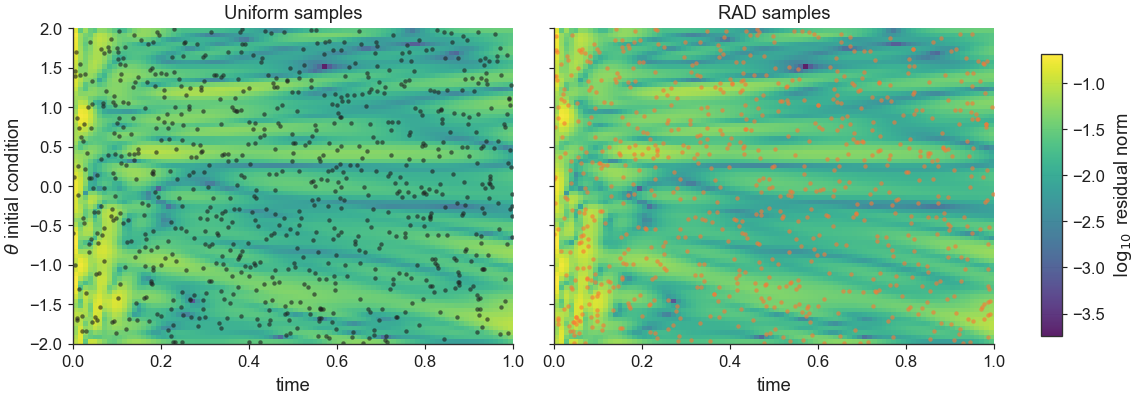

In [8]:
CHAPTER_FIGURE_DIR = REPO / "Chapters" / "6_Results"
CHAPTER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with plt.rc_context({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.55), sharex=True, sharey=True)
    heatmap_extent = [
        residual_time_grid.min(),
        residual_time_grid.max(),
        residual_theta_grid.min(),
        residual_theta_grid.max(),
    ]
    panel_specs = [
        (axes[0], "Uniform samples", uniform_sample_time, uniform_sample_theta, NEUTRAL_COLORS["text"]),
        (axes[1], "RAD samples", rad_sample_time, rad_sample_theta, DTU_COLORS["orange"]),
    ]
    heatmap = None
    for ax, title, sample_time, sample_theta, sample_color in panel_specs:
        heatmap = ax.imshow(
            log_residual,
            origin="lower",
            aspect="auto",
            extent=heatmap_extent,
            cmap="viridis",
            vmin=residual_vmin,
            vmax=residual_vmax,
            alpha=0.88,
            interpolation="nearest",
        )
        ax.scatter(
            sample_time,
            sample_theta,
            s=7,
            c=sample_color,
            alpha=0.62,
            linewidths=0,
            rasterized=True,
        )
        ax.set_title(title)
        ax.set_xlabel("time")
        ax.grid(False)
        apply_thesis_axis_style(ax)
    axes[0].set_ylabel(r"$\theta$ initial condition")
    fig.tight_layout(rect=(0.0, 0.0, 0.90, 1.0))
    cbar_ax = fig.add_axes([0.915, 0.18, 0.018, 0.66])
    colorbar = fig.colorbar(heatmap, cax=cbar_ax)
    colorbar.set_label(r"$\log_{10}$ residual norm")
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(CHAPTER_FIGURE_DIR / "collocation_residual_sampling.png", dpi=300, bbox_inches="tight")
    plt.show()


## Convergence And Physics Residual Evolution

Representative convergence behaviour is shown for the highest collocation density. Curves are averaged across seeds and smoothed with a rolling median to emphasize the training trend rather than validation cadence noise.

In [9]:
CONVERGENCE_DENSITY = "p64k"
CONVERGENCE_STRATEGIES = ["uniform_lhs", "rad"]
CONVERGENCE_METRICS = ["val_physics_loss", "val_total_loss"]
CONVERGENCE_SMOOTH_WINDOW = 200

convergence_frames = []
for _, row in runs[
    (runs["density_label"].astype(str) == CONVERGENCE_DENSITY)
    & (runs["strategy"].astype(str).isin(CONVERGENCE_STRATEGIES))
].iterrows():
    path = epoch_metrics_path(ROOT, row["batch"], row["run_name"])
    frame = read_epoch_metrics(path, columns=["global_epoch", *CONVERGENCE_METRICS])
    if frame.empty:
        continue
    frame["strategy"] = str(row["strategy"])
    frame["seed_label"] = str(row["seed_label"])
    convergence_frames.append(frame)

if not convergence_frames:
    raise FileNotFoundError("No epoch metrics found for the collocation convergence diagnostic.")

collocation_convergence_run = pd.concat(convergence_frames, ignore_index=True, sort=False)
collocation_convergence_run = collocation_convergence_run.dropna(subset=["global_epoch"])

agg_parts = []
for metric in CONVERGENCE_METRICS:
    metric_frame = collocation_convergence_run[["strategy", "global_epoch", "seed_label", metric]].copy()
    metric_frame[metric] = pd.to_numeric(metric_frame[metric], errors="coerce")
    metric_frame = metric_frame.dropna(subset=[metric])
    metric_agg = (
        metric_frame.groupby(["strategy", "global_epoch"], observed=True)
        .agg(
            mean=(metric, "mean"),
            sem=(metric, lambda values: pd.Series(values).dropna().std(ddof=1) / np.sqrt(pd.Series(values).dropna().shape[0]) if pd.Series(values).dropna().shape[0] > 1 else np.nan),
            n_seeds=("seed_label", "nunique"),
        )
        .reset_index()
        .rename(columns={"mean": f"{metric}_mean", "sem": f"{metric}_sem", "n_seeds": f"{metric}_n_seeds"})
    )
    metric_agg[f"{metric}_smooth"] = (
        metric_agg.sort_values(["strategy", "global_epoch"])
        .groupby("strategy", observed=True)[f"{metric}_mean"]
        .transform(lambda values: values.rolling(CONVERGENCE_SMOOTH_WINDOW, min_periods=1, center=True).median())
    )
    agg_parts.append(metric_agg)

collocation_convergence = agg_parts[0]
for part in agg_parts[1:]:
    collocation_convergence = collocation_convergence.merge(part, on=["strategy", "global_epoch"], how="outer")
collocation_convergence["strategy"] = pd.Categorical(
    collocation_convergence["strategy"].astype(str),
    categories=CONVERGENCE_STRATEGIES,
    ordered=True,
)
collocation_convergence = collocation_convergence.sort_values(["strategy", "global_epoch"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.
# collocation_convergence.to_csv(EXPORT / "collocation_convergence_p64k_uniform_vs_rad.csv", index=False)

print(
    f"Loaded convergence traces: rows={len(collocation_convergence_run):,}, "
    f"strategies={', '.join(CONVERGENCE_STRATEGIES)}, density={CONVERGENCE_DENSITY}."
)


Loaded convergence traces: rows=30,006, strategies=uniform_lhs, rad, density=p64k.


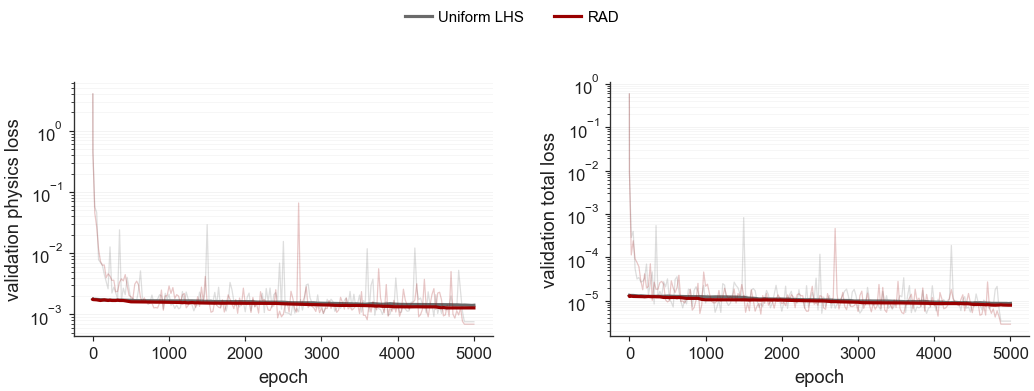

[]

In [10]:
CONVERGENCE_PANELS = [
    ("val_physics_loss", "validation physics loss"),
    ("val_total_loss", "validation total loss"),
]

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.35), sharex=True)
for ax, (metric, ylabel) in zip(axes, CONVERGENCE_PANELS):
    for strategy in CONVERGENCE_STRATEGIES:
        sub = collocation_convergence[collocation_convergence["strategy"].astype(str) == strategy].copy()
        sub = sub.dropna(subset=[f"{metric}_mean", f"{metric}_smooth"])
        if sub.empty:
            continue
        x = sub["global_epoch"].to_numpy(dtype=float)
        y_raw = sub[f"{metric}_mean"].to_numpy(dtype=float)
        y_smooth = sub[f"{metric}_smooth"].to_numpy(dtype=float)
        color = STRATEGY_COLORS[strategy]
        ax.plot(
            x,
            y_raw,
            color=color,
            linewidth=0.75,
            alpha=0.22,
        )
        ax.plot(
            x,
            y_smooth,
            color=color,
            linewidth=1.9,
            label=strategy_label(strategy),
        )
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    log_minor_grid(ax, axis="y")
    ax.grid(True, axis="y", alpha=0.38)
    ax.grid(False, axis="x")
    apply_thesis_axis_style(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.02))
fig.subplots_adjust(left=0.085, right=0.990, bottom=0.180, top=0.810, wspace=0.280)
export_fig(fig, "collocation_convergence_p64k_uniform_vs_rad")


## Final Validation Losses Across Collocation Budgets

Final-epoch physics and total validation losses are shown for all three collocation densities and all three sampling strategies. Values are averaged across seeds; error bars show ±1 SEM.

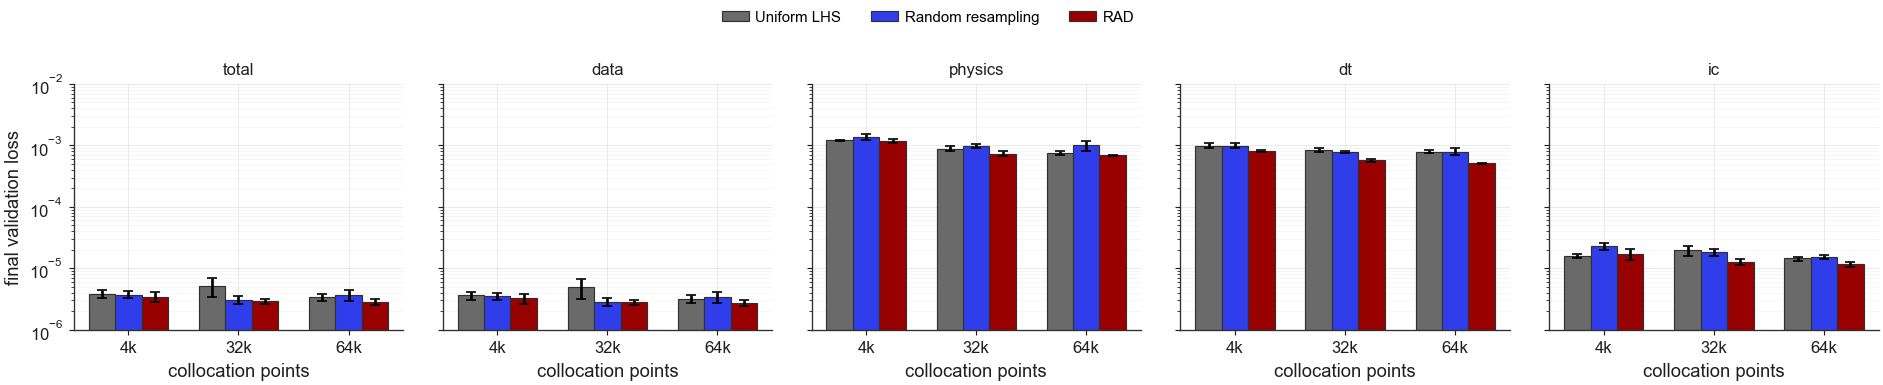

[]

In [11]:
FINAL_VAL_METRICS = [
    "val_total_loss",
    "val_data_loss",
    "val_physics_loss",
    "val_dt_loss",
    "val_ic_loss",
]
FINAL_VAL_TITLES = {
    "val_total_loss": "total",
    "val_data_loss": "data",
    "val_physics_loss": "physics",
    "val_dt_loss": "dt",
    "val_ic_loss": "ic",
}

final_val_rows = []
for _, row in runs.iterrows():
    path = epoch_metrics_path(ROOT, row["batch"], row["run_name"])
    frame = read_epoch_metrics(path, columns=["global_epoch", *FINAL_VAL_METRICS])
    if frame.empty:
        continue
    last = frame.sort_values("global_epoch").iloc[-1]
    final_val_rows.append({
        "density_label": str(row["density_label"]),
        "strategy": str(row["strategy"]),
        "seed_label": str(row["seed_label"]),
        **{
            metric: float(last[metric]) if metric in last.index and pd.notna(last[metric]) else np.nan
            for metric in FINAL_VAL_METRICS
        },
    })

final_val_df = pd.DataFrame(final_val_rows)

final_val_agg_rows = []
for density in DENSITY_ORDER:
    for strategy in STRATEGY_ORDER:
        subset = final_val_df[
            (final_val_df["density_label"] == density) & (final_val_df["strategy"] == strategy)
        ]
        record = {"density_label": density, "strategy": strategy}
        for metric in FINAL_VAL_METRICS:
            vals = subset[metric].dropna().to_numpy(dtype=float)
            record[f"{metric}_mean"] = vals.mean() if len(vals) > 0 else np.nan
            record[f"{metric}_sem"] = (vals.std(ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan
        final_val_agg_rows.append(record)

final_val_agg = pd.DataFrame(final_val_agg_rows)

all_values = []
all_errors = []
for metric in FINAL_VAL_METRICS:
    all_values.append(final_val_agg[f"{metric}_mean"].to_numpy(dtype=float))
    all_errors.append(np.nan_to_num(final_val_agg[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0))
shared_ylim = log_limits(np.concatenate(all_values), np.concatenate(all_errors))

fig, axes = plt.subplots(1, 5, figsize=(16.0, 3.25), sharex=True, sharey=True)
x = np.arange(len(DENSITY_ORDER))
width = 0.24
for ax, metric in zip(axes, FINAL_VAL_METRICS):
    for offset_idx, strategy in enumerate(STRATEGY_ORDER):
        sub = (
            final_val_agg[final_val_agg["strategy"] == strategy]
            .set_index("density_label")
            .reindex(DENSITY_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        errs = np.nan_to_num(sub[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0)
        ax.bar(
            x + (offset_idx - 1) * width,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            color=STRATEGY_COLORS[strategy],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=strategy_label(strategy),
        )
    ax.set_xticks(x)
    ax.set_xticklabels([density_label(d) for d in DENSITY_ORDER])
    ax.set_xlabel("collocation points")
    ax.set_title(FINAL_VAL_TITLES[metric])
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=20))
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)

axes[0].set_ylim(*shared_ylim)
axes[0].set_ylabel("final validation loss")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.03))
fig.subplots_adjust(left=0.055, right=0.995, bottom=0.180, top=0.810, wspace=0.120)
export_fig(fig, "collocation_final_val_losses_grouped_bars")

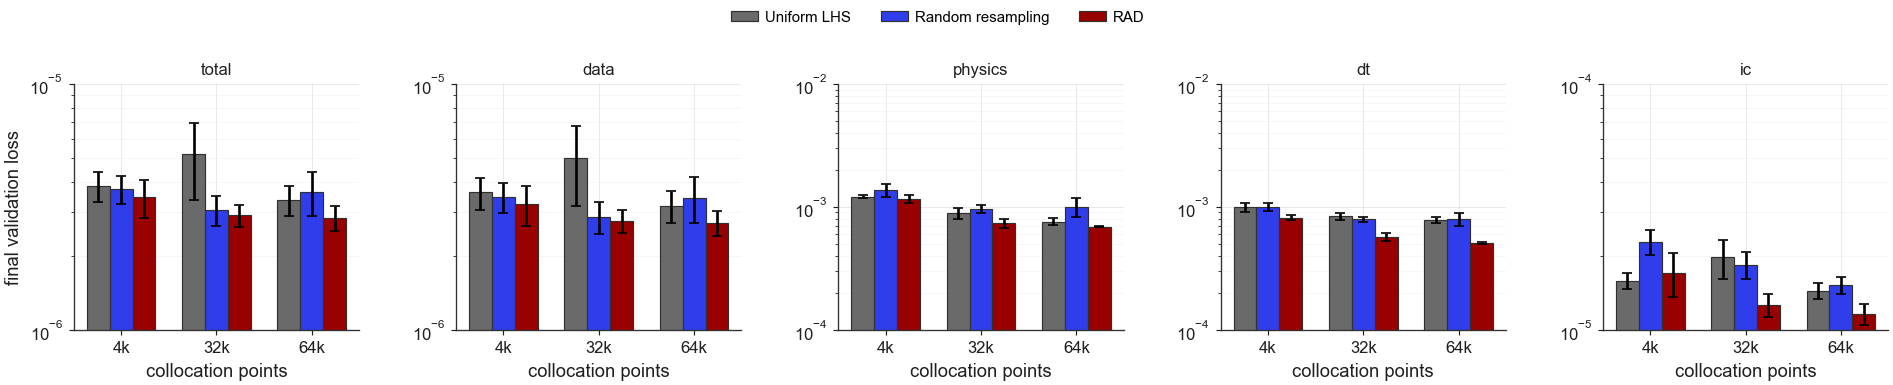

[]

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(16.0, 3.25), sharex=True)
x = np.arange(len(DENSITY_ORDER))
width = 0.24
for ax, metric in zip(axes, FINAL_VAL_METRICS):
    panel_values = []
    panel_errors = []
    for offset_idx, strategy in enumerate(STRATEGY_ORDER):
        sub = (
            final_val_agg[final_val_agg["strategy"] == strategy]
            .set_index("density_label")
            .reindex(DENSITY_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        errs = np.nan_to_num(sub[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0)
        panel_values.append(means)
        panel_errors.append(errs)
        ax.bar(
            x + (offset_idx - 1) * width,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            color=STRATEGY_COLORS[strategy],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=strategy_label(strategy),
        )
    values = np.concatenate(panel_values)
    errors = np.concatenate(panel_errors)
    ax.set_ylim(*log_limits(values, errors))
    ax.set_xticks(x)
    ax.set_xticklabels([density_label(d) for d in DENSITY_ORDER])
    ax.set_xlabel("collocation points")
    ax.set_title(FINAL_VAL_TITLES[metric])
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=20))
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)

axes[0].set_ylabel("final validation loss")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.03))
fig.subplots_adjust(left=0.050, right=0.995, bottom=0.180, top=0.810, wspace=0.340)
export_fig(fig, "collocation_final_val_losses_grouped_bars_indep_y")

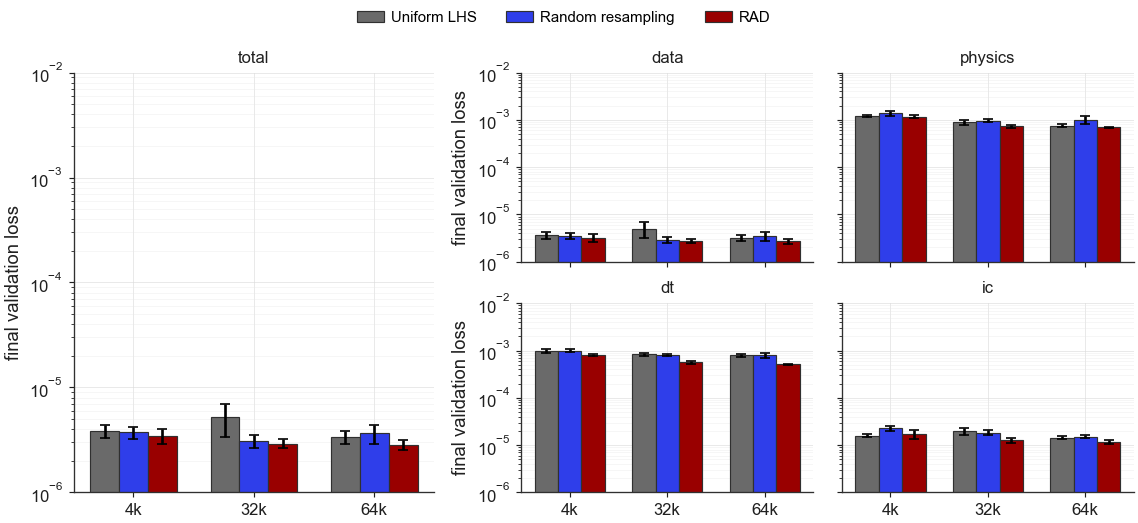

[]

In [13]:
COMPONENT_METRICS = ["val_data_loss", "val_physics_loss", "val_dt_loss", "val_ic_loss"]

fig = plt.figure(figsize=(9.6, 4.4))
gs_outer = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.7], wspace=0.18)
ax_total = fig.add_subplot(gs_outer[0])
gs_right = gs_outer[1].subgridspec(2, 2, hspace=0.22, wspace=0.10)
ax_components = {
    "val_data_loss": fig.add_subplot(gs_right[0, 0], sharey=ax_total),
    "val_physics_loss": fig.add_subplot(gs_right[0, 1], sharey=ax_total),
    "val_dt_loss": fig.add_subplot(gs_right[1, 0], sharey=ax_total),
    "val_ic_loss": fig.add_subplot(gs_right[1, 1], sharey=ax_total),
}

x = np.arange(len(DENSITY_ORDER))
width = 0.24


def draw_panel(ax, metric):
    for offset_idx, strategy in enumerate(STRATEGY_ORDER):
        sub = (
            final_val_agg[final_val_agg["strategy"] == strategy]
            .set_index("density_label")
            .reindex(DENSITY_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        errs = np.nan_to_num(sub[f"{metric}_sem"].to_numpy(dtype=float), nan=0.0)
        ax.bar(
            x + (offset_idx - 1) * width,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            color=STRATEGY_COLORS[strategy],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=strategy_label(strategy),
        )
    ax.set_xticks(x)
    ax.set_xticklabels([density_label(d) for d in DENSITY_ORDER])
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=20))
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)


draw_panel(ax_total, "val_total_loss")
ax_total.set_title(FINAL_VAL_TITLES["val_total_loss"])
ax_total.set_ylabel("final validation loss")
ax_total.set_ylim(*shared_ylim)

for metric, ax in ax_components.items():
    draw_panel(ax, metric)
    ax.set_title(FINAL_VAL_TITLES[metric])

ax_components["val_data_loss"].set_ylabel("final validation loss")
ax_components["val_dt_loss"].set_ylabel("final validation loss")

for metric in ("val_data_loss", "val_physics_loss"):
    plt.setp(ax_components[metric].get_xticklabels(), visible=False)
for metric in ("val_physics_loss", "val_ic_loss"):
    plt.setp(ax_components[metric].get_yticklabels(), visible=False)

handles, labels = ax_total.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
fig.subplots_adjust(left=0.075, right=0.995, bottom=0.085, top=0.880)
export_fig(fig, "collocation_final_val_losses_total_vs_components")


In [14]:
def pct_change(new: float, ref: float) -> float:
    if not np.isfinite(new) or not np.isfinite(ref) or ref == 0.0:
        return np.nan
    return (new - ref) / ref * 100.0


vs_baseline_rows = []
for density in DENSITY_ORDER:
    baseline = (
        final_val_agg[(final_val_agg["density_label"] == density) & (final_val_agg["strategy"] == "uniform_lhs")]
        .iloc[0]
    )
    for strategy in ("random_resampling", "rad"):
        method = (
            final_val_agg[(final_val_agg["density_label"] == density) & (final_val_agg["strategy"] == strategy)]
            .iloc[0]
        )
        record = {"Budget": density_label(density), "Strategy": strategy_label(strategy)}
        for metric in FINAL_VAL_METRICS:
            record[FINAL_VAL_TITLES[metric]] = f"{pct_change(method[f'{metric}_mean'], baseline[f'{metric}_mean']):+.1f}%"
        vs_baseline_rows.append(record)

vs_baseline_table = pd.DataFrame(vs_baseline_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# vs_baseline_table.to_csv(EXPORT / "final_val_losses_vs_lhs_baseline.csv", index=False)
print("Percentage change in final validation loss vs uniform LHS at the same budget (negative = improvement):")
display(vs_baseline_table)


vs_budget_rows = []
for strategy in STRATEGY_ORDER:
    base = (
        final_val_agg[(final_val_agg["density_label"] == "p4k") & (final_val_agg["strategy"] == strategy)]
        .iloc[0]
    )
    for density in ("p32k", "p64k"):
        higher = (
            final_val_agg[(final_val_agg["density_label"] == density) & (final_val_agg["strategy"] == strategy)]
            .iloc[0]
        )
        record = {"Strategy": strategy_label(strategy), "Budget": f"4k -> {density_label(density)}"}
        for metric in FINAL_VAL_METRICS:
            record[FINAL_VAL_TITLES[metric]] = f"{pct_change(higher[f'{metric}_mean'], base[f'{metric}_mean']):+.1f}%"
        vs_budget_rows.append(record)

vs_budget_table = pd.DataFrame(vs_budget_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# vs_budget_table.to_csv(EXPORT / "final_val_losses_vs_budget.csv", index=False)
print("Percentage change in final validation loss when scaling the collocation budget within a strategy (negative = improvement):")
display(vs_budget_table)


Percentage change in final validation loss vs uniform LHS at the same budget (negative = improvement):


,Budget,Strategy,total,data,physics,dt,ic
0,4k,Random resampling,-3.0%,-3.8%,+13.4%,+0.1%,+43.4%
1,4k,RAD,-10.3%,-10.4%,-3.1%,-17.9%,+7.7%
2,32k,Random resampling,-40.7%,-42.3%,+9.2%,-5.7%,-6.5%
3,32k,RAD,-43.6%,-44.3%,-16.7%,-31.9%,-36.1%
4,64k,Random resampling,+8.2%,+7.9%,+32.1%,+1.2%,+5.1%
5,64k,RAD,-15.1%,-14.7%,-8.8%,-35.4%,-19.7%


Percentage change in final validation loss when scaling the collocation budget within a strategy (negative = improvement):


,Strategy,Budget,total,data,physics,dt,ic
0,Uniform LHS,4k -> 32k,+34.2%,+37.6%,-26.7%,-15.7%,+24.1%
1,Uniform LHS,4k -> 64k,-12.7%,-11.7%,-37.1%,-21.0%,-9.0%
2,Random resampling,4k -> 32k,-17.9%,-17.4%,-29.4%,-20.5%,-19.1%
3,Random resampling,4k -> 64k,-2.6%,-0.9%,-26.8%,-20.1%,-33.3%
4,RAD,4k -> 32k,-15.6%,-14.4%,-37.0%,-30.1%,-26.3%
5,RAD,4k -> 64k,-17.4%,-15.9%,-40.8%,-37.8%,-32.2%
